# FastRelax

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/kdidi/sphinx-docs/docs/tutorial/06_fast_relax.ipynb)

> **Prerequisite.** Complete [Packing and a Small Mutation Scan](04_packing_and_mutation_scan.ipynb) and [Minimization, constraints, and kinematics](05_minimization_constraints_kinematics.ipynb). FastRelax composes those packing and minimization primitives.

## Goals

This tutorial runs a deliberately small FastRelax example and explains the protocol rather than presenting it as an exact Rosetta port. You will:

- build the required `PackerPalette`, move map, and `FoldForest`;
- run one repeat on a checked-in 1UBQ slice;
- inspect the `fa_rep` and coordinate-constraint ramp;
- compare the score and structure before and after relaxation;
- relax a four-member ensemble in one GPU batch and click through every result; and
- see the verified adapter signature for optional kinematic minimization.

## Setup

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "kdidi/sphinx-docs/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol import beta2016_score_function
from tmol.io.pose_stack_from_biotite import pose_stack_from_biotite
from tmol.kinematics.fold_forest import FoldForest
from tmol.kinematics.move_map import CartesianMoveMap, MoveMap
from tmol.optimization.minimizers import run_cart_min, run_kin_min
from tmol.pack.packer_task import PackerPalette
from tmol.pose.pose_stack_builder import PoseStackBuilder
from tmol.relax.fast_relax import fast_relax
from tmol.score.constraint.utility import create_mainchain_coordinate_constraints
from tmol.score.score_types import ScoreType

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def total_score(pose_stack, score_function):
    scorer = score_function.render_whole_pose_scoring_module(pose_stack)
    return float(scorer(pose_stack.coords).detach().cpu()[0])


def score_components(pose_stack, score_function):
    scorer = score_function.render_whole_pose_scoring_module(pose_stack)
    weighted_terms = scorer(
        pose_stack.coords, sum_terms=False, apply_weights=True
    )[:, 0]
    score_types = score_function.all_score_types()
    constraint_index = next(
        index
        for index, score_type in enumerate(score_types)
        if score_type == ScoreType.constraint
    )
    constraint_score = weighted_terms[constraint_index]
    non_constraint_score = weighted_terms.sum() - constraint_score
    return {
        "non_constraint_score": float(non_constraint_score.detach().cpu()),
        "constraint_score": float(constraint_score.detach().cpu()),
        "reported_total": float(weighted_terms.sum().detach().cpu()),
    }

## Protocol and ramp schedule

TMol's `fast_relax(pose_stack, sfxn, packer_pallete, move_map, fold_forest, *, ...)` alternates rotamer packing and minimization. Each schedule entry independently scales the starting `fa_rep` weight for packing and minimization and can scale the starting coordinate-constraint weight. The final minimization fraction should be `1.0` so the accepted structure is evaluated with full repulsion.

The production default is a four-step MonomerRelax2019-derived schedule. This tutorial uses two steps and one repeat to keep the checked-in example small. The default `min_fn=None` is Cartesian; therefore the workflow passes a `CartesianMoveMap`.

In [3]:
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol" / "tests" / "data" / "cif" / "1UBQ.cif"
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 6)]
setup_diagnostics = StringIO()
try:
    with redirect_stdout(setup_diagnostics), redirect_stderr(setup_diagnostics):
        pose = pose_stack_from_biotite(protein_slice, device, no_optH=True)
        relax_start = create_mainchain_coordinate_constraints(pose)
except Exception:
    print(setup_diagnostics.getvalue())
    raise

score_function = beta2016_score_function(device)
score_function.set_weight(ScoreType.constraint, 1.0)
fa_rep_start = float(score_function.get_weight(ScoreType.fa_ljrep))
constraint_start = float(score_function.get_weight(ScoreType.constraint))

palette = PackerPalette()
cartesian_move_map = CartesianMoveMap()
fold_forest = FoldForest.reasonable_fold_forest(relax_start)
tiny_schedule = [
    {"fa_rep_pack_frac": 0.10, "fa_rep_min_frac": 0.20, "cst_frac": 1.0},
    {"fa_rep_pack_frac": 1.00, "fa_rep_min_frac": 1.00, "cst_frac": 0.0},
]

schedule_table = pd.DataFrame(tiny_schedule)
schedule_table["fa_rep_pack_weight"] = (
    schedule_table["fa_rep_pack_frac"] * fa_rep_start
)
schedule_table["fa_rep_min_weight"] = (
    schedule_table["fa_rep_min_frac"] * fa_rep_start
)
schedule_table["constraint_weight"] = schedule_table["cst_frac"] * constraint_start
print("input:", cif_path.name)
show_table(schedule_table)

input: 1UBQ.cif


## Run one repeat

The schedule table should show low repulsion in the first stage and full repulsion in the final stage, while the coordinate-constraint weight ramps to zero. If the constraint column is zero in every row, check both the score-function constraint weight and the pose's attached `ConstraintSet`.

The call below uses the complete current signature: pose, score function, palette, move map, and fold forest are positional; protocol controls are keyword-only. Coordinate constraints are already attached to `relax_start`, and the score function has a non-zero constraint weight, so `cst_frac` values in the schedule are active.

In [4]:
relax_stage_poses = []


def recording_cart_min(
    pose_stack, stage_score_function, *, fold_forest, move_map, verbose
):
    del fold_forest
    coord_mask = move_map.coord_mask if isinstance(move_map, CartesianMoveMap) else None
    minimized = run_cart_min(
        pose_stack,
        stage_score_function,
        coord_mask=coord_mask,
        verbose=verbose,
        optimizer_kwargs={"verbose": verbose},
    )
    relax_stage_poses.append(minimized.clone())
    return minimized


before_components = score_components(relax_start, score_function)
relaxed = fast_relax(
    relax_start,
    score_function,
    palette,
    cartesian_move_map,
    fold_forest,
    num_repeats=1,
    schedule=tiny_schedule,
    ramp_constraints=True,
    min_fn=recording_cart_min,
    verbose=False,
)
after_components = score_components(relaxed, score_function)

score_frame = pd.DataFrame(
    [
        {"structure": "before", **before_components},
        {"structure": "after", **after_components},
    ]
)
score_frame["non_constraint_score_change"] = (
    score_frame["non_constraint_score"]
    - before_components["non_constraint_score"]
)
show_table(score_frame)

/home/runner/work/tmol/tmol/tmol/score/constraint/constraint_energy_term.py:465: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:816.)
  sparse_scores = torch.sparse_coo_tensor(


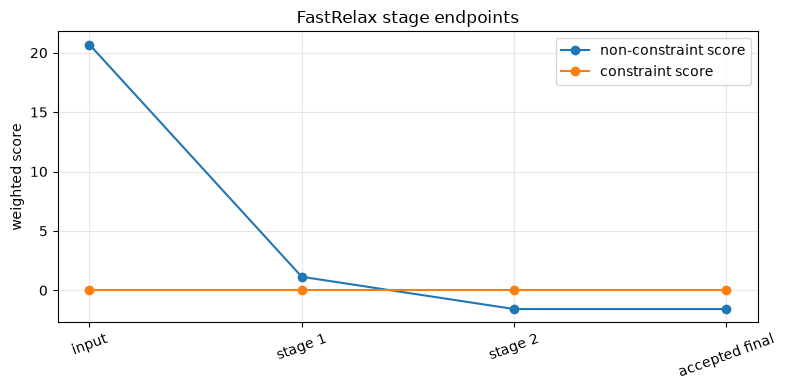

In [5]:
trajectory_structures = {"input": relax_start}
trajectory_structures.update(
    {
        f"stage {stage_index + 1}": stage_pose
        for stage_index, stage_pose in enumerate(relax_stage_poses)
    }
)
trajectory_structures["accepted final"] = relaxed

trajectory_rows = []
trajectory_notes = {}
for frame_index, (label, frame_pose) in enumerate(trajectory_structures.items()):
    components = score_components(frame_pose, score_function)
    trajectory_rows.append({"frame": frame_index, "label": label, **components})
    trajectory_notes[label] = (
        f"non-constraint {components['non_constraint_score']:.3f}; "
        f"constraint {components['constraint_score']:.3f}"
    )
trajectory_frame = pd.DataFrame(trajectory_rows)
show_table(trajectory_frame)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    trajectory_frame["frame"],
    trajectory_frame["non_constraint_score"],
    marker="o",
    label="non-constraint score",
)
ax.plot(
    trajectory_frame["frame"],
    trajectory_frame["constraint_score"],
    marker="o",
    label="constraint score",
)
ax.set(
    xticks=trajectory_frame["frame"],
    xticklabels=trajectory_frame["label"],
    ylabel="weighted score",
    title="FastRelax stage endpoints",
)
ax.tick_params(axis="x", rotation=20)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(
    tmol.switchable_view(
        trajectory_structures,
        notes=trajectory_notes,
    )
)

**Expected observations.** The non-constraint and constraint components must be finite. “Non-constraint” is the exact description: it includes every weighted beta2016 term except the coordinate-constraint term, including empirical/statistical contributions. `fast_relax()` restores the starting constraint weight before returning, so `reported_total` is split rather than being mistaken for the final `cst_frac=0` optimization objective. The structure switcher records minimization endpoints for each pack/min stage and the final accept-to-best result; it does not contain LBFGS line-search evaluations or internal packing trajectories.

A tiny pedagogical schedule is not guaranteed to improve every input. Large distortions, NaNs, or a missing ligand/residue are failures, not expected stochastic variation.

## Optional kinematic minimizer

`fast_relax` calls a custom minimizer as `min_fn(pose_stack, sfxn, *, fold_forest, move_map, verbose)`. The adapter below uses the verified `run_kin_min(pose_stack, sfxn, ff, mm, ...)` signature. To use it, supply a `MoveMap` (not a `CartesianMoveMap`) and pass `min_fn=kinematic_min_fn` to `fast_relax`.

This adapter is shown but not run in the CPU documentation build because it would duplicate the full packing schedule with a different minimizer. Notebook 05 executes both Cartesian and kinematic minimization directly; use that comparison before enabling the more expensive FastRelax variant here.

In [6]:
def kinematic_min_fn(
    pose_stack, score_function, *, fold_forest, move_map, verbose
):
    return run_kin_min(
        pose_stack,
        score_function,
        fold_forest,
        move_map,
        optimizer_kwargs={"max_iter": 10, "verbose": verbose},
        verbose=verbose,
    )

kinematic_move_map = MoveMap.from_pose_stack(relax_start)
kinematic_move_map.move_all_named_torsions = True
# Example extension (not run here):
# kin_relaxed = fast_relax(
#     relax_start, score_function, palette, kinematic_move_map, fold_forest,
#     num_repeats=1, schedule=tiny_schedule, min_fn=kinematic_min_fn,
# )

## Relax an ensemble in one GPU batch

The single-structure call above and the batched call below use the same protocol. Four reproducibly perturbed conformations are assembled into one `PoseStack`, relaxed together, scored together, and split only for the labeled structure switcher. This exposes the batch dimension to GPU kernels; measure it against four serial calls on the target GPU before choosing a production batch size.

The cell is marked `gpu-only`: CPU documentation CI preserves the code and records a skip message, while the Colab button at the top opens a GPU runtime where it can be executed.

In [7]:
#| tags: [gpu-only]
if device.type != "cuda":
    print("Skipped: open this notebook in a Colab GPU runtime to run batch relax.")
else:
    ensemble_members = {}
    for member_index, noise_scale in enumerate((0.00, 0.01, 0.02, 0.03)):
        member = pose.clone()
        generator = torch.Generator(device=device).manual_seed(SEED + member_index)
        noise = torch.randn(
            member.coords.shape,
            generator=generator,
            device=device,
            dtype=member.coords.dtype,
        )
        member.coords[member.real_atoms] += noise[member.real_atoms] * noise_scale
        ensemble_members[f"input {member_index}"] = member

    ensemble = PoseStackBuilder.from_poses(
        list(ensemble_members.values()), device
    )
    ensemble_fold_forest = FoldForest.reasonable_fold_forest(ensemble)
    ensemble_sfxn = beta2016_score_function(device)
    ensemble_scorer = ensemble_sfxn.render_whole_pose_scoring_module(ensemble)
    with torch.no_grad():
        ensemble_before = ensemble_scorer(ensemble.coords).detach().cpu()

    relaxed_ensemble = fast_relax(
        ensemble,
        ensemble_sfxn,
        PackerPalette(),
        CartesianMoveMap(),
        ensemble_fold_forest,
        num_repeats=1,
        schedule=tiny_schedule,
        verbose=False,
    )
    relaxed_scorer = ensemble_sfxn.render_whole_pose_scoring_module(
        relaxed_ensemble
    )
    with torch.no_grad():
        ensemble_after = relaxed_scorer(
            relaxed_ensemble.coords
        ).detach().cpu()

    ensemble_frame = pd.DataFrame(
        {
            "member": list(range(ensemble.n_poses)),
            "score_before": ensemble_before.numpy(),
            "score_after": ensemble_after.numpy(),
        }
    )
    ensemble_frame["score_change"] = (
        ensemble_frame["score_after"] - ensemble_frame["score_before"]
    )
    show_table(ensemble_frame)

    comparison_structures = {}
    comparison_notes = {}
    for member_index in range(ensemble.n_poses):
        before_label = f"member {member_index} — before"
        after_label = f"member {member_index} — after"
        comparison_structures[before_label] = ensemble.split(member_index)
        comparison_structures[after_label] = relaxed_ensemble.split(member_index)
        comparison_notes[before_label] = (
            f"score {ensemble_before[member_index]:.3f}"
        )
        comparison_notes[after_label] = (
            f"score {ensemble_after[member_index]:.3f}"
        )
    display(
        tmol.switchable_view(
            comparison_structures,
            notes=comparison_notes,
        )
    )

Skipped by CPU documentation build: this cell requires CUDA.


## Rosetta comparison

Both protocols alternate side-chain repacking with minimization while ramping steric repulsion, and both can ramp coordinate constraints. Rosetta FastRelax has a mature script language, MoveMap factories, symmetry and membrane integrations, and many protocol options. TMol implements a smaller tensor-native subset: a Python schedule, `PackerTask` operations, Cartesian minimization by default, an optional callable minimizer, and accept-to-best across repeats.

The algorithms and score functions are not numerically interchangeable. Treat TMol FastRelax as partial protocol parity for batched refinement, not as an exact port or a guarantee of reproducing Rosetta trajectories.

## Limitations

- The two-step schedule is pedagogical, not a recommended production schedule.
- Results depend on the score function, available conformer samplers, device, dtype, and optimizer.
- FastRelax does not perform docking, backbone assembly, or global sampling.
- TMol restores the starting constraint weight after the protocol; compare physical and constraint components explicitly.
- The recording `min_fn` captures accepted minimization endpoints, not rejected line-search trials or internal packing trajectories.
- A custom `min_fn` is an extension point, so its compatibility and convergence behavior are the caller's responsibility.

## Exercises

1. Replace the tiny schedule with `DEFAULT_RELAX_SCHEDULE` and compare runtime and score.
2. Keep constraints active in the final step and compare Cα displacement.
3. Pass `kinematic_min_fn` with the prepared `kinematic_move_map` and compare Cartesian and kinematic results.
4. Write a task operation that restricts packing to a selected block mask.
5. Batch two small poses and inspect accept-to-best behavior per pose.

## References

- [Rosetta Relax tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/Relax_Tutorial/Relax)
- [Rosetta FastRelax implementation](https://github.com/RosettaCommons/rosetta/blob/main/source/src/protocols/relax/FastRelax.cc)
- [PyRosetta packing, design, and regional relax](https://github.com/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.02-Packing-design-and-regional-relax.ipynb)
- [PyRosetta refinement documentation](https://www.pyrosetta.org/documentation)